# 36 - Sampling f̃ = f_acc/(1 + f_acc) instead of f_acc

f_acc is the accDM parent density relative to the stable CDM, ω_acc = f_acc·ω_cdm. The accDM share of the dark
matter is

$$\tilde f = \frac{f_{\rm acc}}{1 + f_{\rm acc}} = \frac{\omega_{\rm acc}}{\omega_{\rm cdm} + \omega_{\rm acc}},$$

exactly before the transition, and today the daughters' share up to their leftover kinetic energy (nb34, 1b).
`input.c` now accepts `f_tilde` in place of `f_acc` (not both): CLASS sets f_acc = f̃/(1 − f̃) and nothing
downstream changes. f̃ must lie in [0, 1): at f̃ = 1 there is no stable CDM, and the parent is defined as
f_acc·ω_cdm.

Together with `omega_dm_tot` (nb34) the dark-matter split becomes linear in f̃:

| inputs | ω_cdm | parent ω_acc (≈ daughter today) |
|---|---|---|
| ω_cdm, f_acc | input | f_acc·ω_cdm |
| ω_dm,tot, f_acc | ω_dm,tot/(1 + f_acc) | ω_dm,tot·f_acc/(1 + f_acc) |
| ω_dm,tot, f̃ | ω_dm,tot·(1 − f̃) | ω_dm,tot·f̃ |

- **1** checks that all four input combinations give identical output, and that bad inputs are rejected.
- **2** checks what f̃ measures: the parent share before the transition and the accDM share today.
- **3** explores f̃ → 1 (f_acc ≫ 10), which a flat f̃ prior on [0, 1] opens up: does CLASS run, at what cost,
  and is the daughter still resolved.
- **4** compares how observables respond to f̃ and to f_acc.
- **5** compares the implied priors and reweights the fixed-mass CONNECT chains.
- **6** compares how a first-iteration Latin hypercube covers each mass's posterior.

Chains: `chains/fixed_masses/connect/new`, 30% burn-in. They sample flat (ω_dm,tot, f_acc) with
f_acc ∈ [0, f_max], f_max = 1 at 10¹³ GeV, 5 at 10¹⁴ GeV and 10 elsewhere (read from each `log.param`). Runtime about 15 min (sections 1–4 run CLASS, ~8 s per full run, ~40 s at 200 bins/decade).

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from classy import Class

import figkit as fk

fk.use('quick')


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


CHAINS = find_root()/'chains'/'fixed_masses'/'connect'/'new'
BURN_IN = 0.3


def is_mass(name):
    try:
        float(name)
        return True
    except ValueError:
        return False


def chain_dirs():
    """Fixed-mass chain folders (named by log10 m) that hold chain files, by mass."""
    dirs = [d for d in CHAINS.iterdir() if d.is_dir() and is_mass(d.name) and any(d.glob('*__*.txt'))]
    return sorted(dirs, key=lambda d: float(d.name))


def f_acc_upper(directory):
    """Upper prior bound on f_acc in the chain's log.param."""
    for line in open(directory/'log.param'):
        if line.startswith("data.parameters['f_acc']"):
            return float(line.split('=')[1].strip(' []\n').split(',')[2])
    raise KeyError('f_acc not in {}/log.param'.format(directory))


def load_chain(directory):
    """Post-burn-in samples of one MontePython chain folder, with omega_cdm and f_tilde added."""
    names = [line.split()[0] for line in open(next(directory.glob('*_.paramnames')))]
    assert 'omega_dm_tot' in names and 'f_acc' in names, names
    blocks = []
    for path in sorted(directory.glob('*__*.txt')):
        data = pd.read_csv(path, sep=r'\s+', header=None, comment='#').to_numpy()
        blocks.append(data[int(BURN_IN*len(data)):])
    data = np.vstack(blocks)
    out = {'weight': data[:, 0], 'mloglike': data[:, 1]}
    out.update({name: data[:, 2 + i] for i, name in enumerate(names)})
    out['omega_b'] = 1e-2*out['omega_b']                     # MontePython stores 100 omega_b
    out['omega_cdm'] = out['omega_dm_tot']/(1 + out['f_acc'])
    out['f_tilde'] = out['f_acc']/(1 + out['f_acc'])
    out['f_max'] = f_acc_upper(directory)
    return out


def wmean(x, w):
    return np.sum(w*x)/np.sum(w)


def wquantile(x, w, q):
    order = np.argsort(x)
    cdf = np.cumsum(w[order])
    return np.interp(q*cdf[-1], cdf, x[order])


def ess(w):
    return w.sum()**2/np.sum(w**2)


# extra_input of the fixed-mass CONNECT emulators; mass, f_acc and the cosmology are set per run
SETTINGS = {'k_pivot': 0.05, 'lensing': 'yes', 'N_ur': 2.0308, 'N_ncdm': 2, 'deg_ncdm': '1, 1',
            'm_ncdm': '0.06, 0.01', 'T_ncdm': '0.71611, 1.0', 'ncdm_quadrature_strategy': '0, 5',
            'ncdm_fluid_approximation': 3, 'kappa_acc': 12.1, 'a_t_acc': 0.133,
            'vary_Gamma_acc': 'yes', 'gauge': 'synchronous', 'reionization_z_start_max': 80,
            'evolver': 0, 'P_k_max_1/Mpc': 1., 'output': 'tCl,pCl,lCl,mPk', 'l_max_scalars': 2508}
MPK_SETTINGS = {**{k: v for k, v in SETTINGS.items() if k != 'l_max_scalars'}, 'output': 'mPk', 'lensing': 'no'}

# LCDM best fit of the 10^14 GeV chain, where f_acc ~ 1e-3
BF = read_bestfit(CHAINS/'14'/'14.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}
OMEGA_DM_TOT = BF['omega_dm_tot']
LMAX = 2500
SPECTRA = ('tt', 'ee', 'te', 'pp')
print('fiducial omega_dm_tot = {:.5f} (connect/new/14 best fit)'.format(OMEGA_DM_TOT))


def run(p):
    """sigma8, 100 theta_s, omega_cdm, wall time and (if requested) lensed C_l; {'error': message} if CLASS fails."""
    cosmo = Class()
    cosmo.set(p)
    try:
        t0 = time.time()
        cosmo.compute()
        out = {'time': time.time() - t0,
               'omega_cdm': cosmo.Omega0_cdm()*cosmo.h()**2,
               'sigma8': cosmo.sigma8(),
               '100theta_s': cosmo.theta_s_100()}
        if 'lCl' in p['output']:
            cl = cosmo.lensed_cl(LMAX)
            out.update({s: np.array(cl[s][2:]) for s in SPECTRA})
    except Exception as err:
        out = {'error': str(err).strip().splitlines()[-1]}
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    return out


def show(df, formats):
    """display df with the given per-column format strings; missing values as '-'."""
    out = df.copy().astype(object)
    for col, f in formats.items():
        out[col] = [('-' if pd.isna(v) else f.format(v)) for v in df[col]]
    display(out)


def run_all(fn, jobs):
    """Sequential: CLASS's own OpenMP threads beat a process pool on this machine."""
    return [fn(p) for p in jobs]


def max_dcl(a, b, spectra=SPECTRA):
    """Largest |a - b| over l, relative to max |b|, over the given spectra."""
    return max(np.max(np.abs(a[s] - b[s]))/np.max(np.abs(b[s])) for s in spectra)


SAMPLES = {float(d.name): load_chain(d) for d in chain_dirs()}
print('chains (f_max):', ', '.join('{:g} ({:g})'.format(m, s['f_max']) for m, s in SAMPLES.items()))

/opt/homebrew/Caskroom/miniforge/base/envs/accDM/lib/python3.12/site-packages/figkit/style.py:132: RuntimeWarning: text.usetex requested but latex, dvipng not found on PATH; falling back to matplotlib mathtext. Install TeX Live or MiKTeX (and dvipng) for identical output, or pass usetex=False to silence this.
  usetex = bool(usetex) and latex_available()


fiducial omega_dm_tot = 0.11771 (connect/new/14 best fit)
chains (f_max): 11 (10), 12 (10), 13 (1), 14 (5), 15 (10), 15.301 (10), 15.699 (10), 16 (10), 16.301 (10), 16.699 (10), 17 (10), 17.301 (10), 17.699 (10), 18 (10)


## 1. Same model, four inputs

At m = 10¹⁶ GeV, for each f_acc the model is run from f̃ = f_acc/(1 + f_acc) and from f_acc, with ω_dm,tot or
with ω_cdm. CLASS turns f̃ back into f_acc = f̃/(1 − f̃), which can differ from the nominal f_acc in the last bit
(the `f_acc rt - f_acc` column). The f̃ runs must therefore be **bit-identical** to f_acc runs given that
round-tripped value, with either second coordinate. f_acc = 0 checks the empty-daughter case through f̃ = 0.
How much a last-bit change of f_acc itself moves the output is section 1c.

In [2]:
M_TEST = 1e16
F_TEST = [0.0, 0.3, 1.0, 5.0, 10.0]
common = {**SETTINGS, **LCDM, 'm_acc_in_GeV': M_TEST}


def round_trip(f):
    """f_acc as CLASS recovers it from f_tilde = f/(1 + f) (same IEEE operations as input.c)."""
    ft = f/(1 + f)
    return ft/(1 - ft)


rows = []
nominal = {}
for f in F_TEST:
    ft, frt = f/(1 + f), round_trip(f)
    pairs = {'omega_dm_tot': ({**common, 'omega_dm_tot': OMEGA_DM_TOT, 'f_tilde': ft},
                              {**common, 'omega_dm_tot': OMEGA_DM_TOT, 'f_acc': frt}),
             'omega_cdm':    ({**common, 'omega_cdm': OMEGA_DM_TOT/(1 + frt), 'f_tilde': ft},
                              {**common, 'omega_cdm': OMEGA_DM_TOT/(1 + frt), 'f_acc': frt})}
    for second, (p_ft, p_f) in pairs.items():
        a, b = run(p_ft), run(p_f)
        assert 'error' not in a and 'error' not in b, (a.get('error'), b.get('error'))
        rows.append({'f_acc': f, 'f_tilde': ft, 'with': second, 'f_acc rt - f_acc': frt - f,
                     'omega_cdm': a['omega_cdm'], 'sigma8': a['sigma8'],
                     'max |dC_l|': max_dcl(a, b), '|d sigma8|': abs(a['sigma8'] - b['sigma8']),
                     '|d 100theta_s|': abs(a['100theta_s'] - b['100theta_s'])})
        if second == 'omega_dm_tot':
            nominal[f] = b
same = pd.DataFrame(rows)
show(same.set_index(['f_acc', 'f_tilde', 'with']),
     {'f_acc rt - f_acc': '{:.1e}', 'omega_cdm': '{:.6f}', 'sigma8': '{:.5f}', 'max |dC_l|': '{:.1e}',
      '|d sigma8|': '{:.1e}', '|d 100theta_s|': '{:.1e}'})
worst = same[['max |dC_l|', '|d sigma8|', '|d 100theta_s|']].max()
print('largest f_tilde vs f_acc difference over all runs:\n{}'.format(worst.to_string()))
assert (worst == 0).all()

f_acc rt - f_acc omega_cdm   sigma8 max |dC_l|  \
f_acc f_tilde  with                                                          
0.0   0.000000 omega_dm_tot          0.0e+00  0.117713  0.80819    0.0e+00   
               omega_cdm             0.0e+00  0.117713  0.80819    0.0e+00   
0.3   0.230769 omega_dm_tot          0.0e+00  0.090549  0.74426    0.0e+00   
               omega_cdm             0.0e+00  0.090549  0.74426    0.0e+00   
1.0   0.500000 omega_dm_tot          0.0e+00  0.058857  0.67596    0.0e+00   
               omega_cdm             0.0e+00  0.058857  0.67596    0.0e+00   
5.0   0.833333 omega_dm_tot          1.8e-15  0.019619  0.60248    0.0e+00   
               omega_cdm             1.8e-15  0.019619  0.60248    0.0e+00   
10.0  0.909091 omega_dm_tot         -3.6e-15  0.010701  0.58772    0.0e+00   
               omega_cdm            -3.6e-15  0.010701  0.58772    0.0e+00   

                            |d sigma8| |d 100theta_s|  
f_acc f_tilde  with                                    
0.0   0.000000 omega_dm_tot    0.0e+00        0.0e+00  
               omega_cdm       0.0e+00        0.0e+00  
0.3   0.230769 omega_dm_tot    0.0e+00        0.0e+00  
               omega_cdm       0.0e+00        0.0e+00  
1.0   0.500000 omega_dm_tot    0.0e+00        0.0e+00  
               omega_cdm       0.0e+00        0.0e+00  
5.0   0.833333 omega_dm_tot    0.0e+00        0.0e+00  
               omega_cdm       0.0e+00        0.0e+00  
10.0  0.909091 omega_dm_tot    0.0e+00        0.0e+00  
               omega_cdm       0.0e+00        0.0e+00

largest f_tilde vs f_acc difference over all runs:
max |dC_l|        0.0
|d sigma8|        0.0
|d 100theta_s|    0.0


### 1b. Rejected inputs

These must stop at input with a message naming the problem (background level is enough).

In [3]:
BAD = {'f_acc and f_tilde':           {'f_acc': 1.0, 'f_tilde': 0.5},
       'f_tilde = 1':                 {'f_tilde': 1.0},
       'f_tilde = 1.5':               {'f_tilde': 1.5},
       'f_tilde = -0.1':              {'f_tilde': -0.1},
       'f_tilde, omega_dm_tot and omega_cdm': {'f_tilde': 0.5, 'omega_cdm': 0.06},
       'f_tilde = 0.999999 (accepted)': {'f_tilde': 0.999999}}


def input_error(p):
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute(level=['background'])
        return 'ACCEPTED'
    except Exception as err:
        return str(err).strip().splitlines()[-1].split(' is true; ')[-1]
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()


for label, extra in BAD.items():
    msg = input_error({**common, 'omega_dm_tot': OMEGA_DM_TOT, **extra})
    print('{:<38s} {}'.format(label, msg))
    assert (msg == 'ACCEPTED') == label.endswith('(accepted)')

f_acc and f_tilde                      You can only enter one of 'f_acc' or 'f_tilde'.
f_tilde = 1                            'f_tilde' must be in [0,1), got 1.
f_tilde = 1.5                          'f_tilde' must be in [0,1), got 1.5.
f_tilde = -0.1                         'f_tilde' must be in [0,1), got -0.1.
f_tilde, omega_dm_tot and omega_cdm    You can only enter one of 'Omega_cdm', 'omega_cdm' or 'omega_dm_tot'.
f_tilde = 0.999999 (accepted)          ACCEPTED


### 1c. CLASS jitter under last-bit changes of f_acc

Where the round trip is not exact (f_acc = 5, 10 above), the f̃ run is the f_acc run with f_acc moved by one ulp.
That is not free: CLASS's adaptive steps and approximation switches respond discontinuously to their inputs, so a
relative change of 10⁻¹⁶–10⁻¹² in f_acc moves the lensed spectra by up to ~10⁻⁴ of their peak. Below, f̃ vs nominal
f_acc, and f_acc vs f_acc·(1 + 10⁻¹²) with no f̃ involved, per spectrum (max |ΔC_ℓ| over ℓ relative to max |C_ℓ|,
and the ℓ where it peaks). This is the repeatability floor of any parametrization, and what an emulator sees as noise.

In [4]:
def per_spectrum(a, b):
    out = {}
    for s in SPECTRA:
        d = np.abs(a[s] - b[s])/np.max(np.abs(b[s]))
        out[s] = '{:.1e} (ℓ={})'.format(d.max(), 2 + d.argmax())
    out['|dsigma8|/sigma8'] = '{:.1e}'.format(abs(a['sigma8']/b['sigma8'] - 1))
    return out


rows = []
for f in F_TEST[1:]:
    ref = run({**common, 'omega_dm_tot': OMEGA_DM_TOT, 'f_acc': f})
    eps = run({**common, 'omega_dm_tot': OMEGA_DM_TOT, 'f_acc': f*(1 + 1e-12)})
    rows.append({'f_acc': f, 'compare': 'f_tilde vs nominal f_acc', 'df/f': (round_trip(f) - f)/f,
                 **per_spectrum(nominal[f], ref)})
    rows.append({'f_acc': f, 'compare': 'f_acc (1 + 1e-12) vs f_acc', 'df/f': 1e-12, **per_spectrum(eps, ref)})
jitter = pd.DataFrame(rows).set_index(['f_acc', 'compare'])
show(jitter, {'df/f': '{:.0e}'})

df/f              tt               ee  \
f_acc compare                                                               
0.3   f_tilde vs nominal f_acc     0e+00   0.0e+00 (ℓ=2)    0.0e+00 (ℓ=2)   
      f_acc (1 + 1e-12) vs f_acc   1e-12  2.1e-06 (ℓ=35)  1.4e-05 (ℓ=348)   
1.0   f_tilde vs nominal f_acc     0e+00   0.0e+00 (ℓ=2)    0.0e+00 (ℓ=2)   
      f_acc (1 + 1e-12) vs f_acc   1e-12   4.4e-07 (ℓ=2)    3.1e-08 (ℓ=2)   
5.0   f_tilde vs nominal f_acc     4e-16   4.2e-06 (ℓ=2)  1.4e-05 (ℓ=348)   
      f_acc (1 + 1e-12) vs f_acc   1e-12   4.3e-06 (ℓ=2)  1.4e-05 (ℓ=348)   
10.0  f_tilde vs nominal f_acc    -4e-16   1.7e-05 (ℓ=2)    1.1e-07 (ℓ=4)   
      f_acc (1 + 1e-12) vs f_acc   1e-12   1.7e-05 (ℓ=2)    1.5e-07 (ℓ=4)   

                                              te             pp  \
f_acc compare                                                     
0.3   f_tilde vs nominal f_acc     0.0e+00 (ℓ=2)  0.0e+00 (ℓ=2)   
      f_acc (1 + 1e-12) vs f_acc  4.7e-06 (ℓ=45)  5.3e-07 (ℓ=2)   
1.0   f_tilde vs nominal f_acc     0.0e+00 (ℓ=2)  0.0e+00 (ℓ=2)   
      f_acc (1 + 1e-12) vs f_acc   2.7e-06 (ℓ=2)  2.6e-07 (ℓ=2)   
5.0   f_tilde vs nominal f_acc     3.0e-05 (ℓ=2)  1.7e-06 (ℓ=2)   
      f_acc (1 + 1e-12) vs f_acc   2.9e-05 (ℓ=2)  1.6e-06 (ℓ=2)   
10.0  f_tilde vs nominal f_acc     6.9e-05 (ℓ=2)  9.5e-07 (ℓ=2)   
      f_acc (1 + 1e-12) vs f_acc   8.1e-05 (ℓ=2)  1.2e-06 (ℓ=2)   

                                 |dsigma8|/sigma8  
f_acc compare                                      
0.3   f_tilde vs nominal f_acc            0.0e+00  
      f_acc (1 + 1e-12) vs f_acc          7.4e-10  
1.0   f_tilde vs nominal f_acc            0.0e+00  
      f_acc (1 + 1e-12) vs f_acc          4.2e-11  
5.0   f_tilde vs nominal f_acc            2.2e-09  
      f_acc (1 + 1e-12) vs f_acc          2.6e-09  
10.0  f_tilde vs nominal f_acc            4.0e-09  
      f_acc (1 + 1e-12) vs f_acc          1.7e-10

## 2. What f̃ measures

Background only, at fixed ω_dm,tot. *Early* is the parent share ρ_acc/(ρ_cdm + ρ_acc) at z = 10⁶, long before the
transition; it should equal f̃ to round-off. *Today* is the accDM share (parent + daughter)/(all three) at z = 0.
It exceeds f̃ by the daughters' leftover kinetic energy, which falls with mass (w is the daughter equation of state
today).

In [5]:
def shares(p):
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute(level=['background'])
        bg = cosmo.get_background()
        cdm, par, dau = bg['(.)rho_cdm'], bg['(.)rho_acc_cdm'], bg['(.)rho_ncdm[1]']
        i = np.argmin(np.abs(np.log(1 + bg['z']) - np.log(1 + 1e6)))
        return {'early': par[i]/(cdm[i] + par[i]),
                'today': (par[-1] + dau[-1])/(cdm[-1] + par[-1] + dau[-1]),
                'w today': bg['(.)p_ncdm[1]'][-1]/dau[-1]}
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()


SHARE_M = [11, 12, 14, 16]
SHARE_F = [0.1, 0.5, 0.9, 0.99]
grid = [(lm, ft) for lm in SHARE_M for ft in SHARE_F]
res = run_all(shares, [{**SETTINGS, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT, 'm_acc_in_GeV': 10**lm,
                         'f_tilde': ft} for lm, ft in grid])
share = pd.DataFrame([{'log10m': lm, 'f_tilde': ft, **r} for (lm, ft), r in zip(grid, res)])
share['early - f_tilde'] = share['early'] - share['f_tilde']
share['(today - f_tilde)/f_tilde'] = (share['today'] - share['f_tilde'])/share['f_tilde']
show(share.set_index(['log10m', 'f_tilde'])[['early - f_tilde', 'today', '(today - f_tilde)/f_tilde', 'w today']],
     {'early - f_tilde': '{:.1e}', 'today': '{:.5f}', '(today - f_tilde)/f_tilde': '{:.2e}', 'w today': '{:.2e}'})
assert share['early - f_tilde'].abs().max() < 1e-8

early - f_tilde    today (today - f_tilde)/f_tilde   w today
log10m f_tilde                                                             
11     0.10            1.4e-17  0.10246                  2.46e-02  1.75e-02
       0.50            0.0e+00  0.50675                  1.35e-02  1.75e-02
       0.90            0.0e+00  0.90240                  2.67e-03  1.75e-02
       0.99            0.0e+00  0.99026                  2.66e-04  1.75e-02
12     0.10            1.4e-17  0.10017                  1.75e-03  1.29e-03
       0.50            0.0e+00  0.50048                  9.69e-04  1.29e-03
       0.90            0.0e+00  0.90017                  1.94e-04  1.29e-03
       0.99            0.0e+00  0.99002                  1.94e-05  1.29e-03
14     0.10            1.4e-17  0.10000                  1.59e-05  1.23e-05
       0.50            0.0e+00  0.50000                  8.86e-06  1.23e-05
       0.90            0.0e+00  0.90000                  1.77e-06  1.23e-05
       0.99            0.0e+00  0.99000                  1.77e-07  1.23e-05
16     0.10            1.4e-17  0.10000                 -5.53e-07  1.23e-07
       0.50            0.0e+00  0.50000                 -3.07e-07  1.23e-07
       0.90            0.0e+00  0.90000                 -6.14e-08  1.23e-07
       0.99            0.0e+00  0.99000                 -6.14e-09  1.23e-07

## 3. f̃ → 1

A flat f̃ prior on [0, 1] puts 1/11 ≈ 9% of its mass at f_acc > 10 (f̃ > 0.909), which the current chains never
visit, and ω_cdm = ω_dm,tot(1 − f̃) → 0. Full runs at fixed ω_dm,tot for a warm (10¹² GeV) and a cold (10¹⁶ GeV)
daughter: whether CLASS succeeds, its wall time, and the change of the lensed spectra relative to f̃ = 0.

The daughter is then nearly all the dark matter, so its momentum grid matters most here. The convergence check
reruns f̃ = 0.1, 0.5 and 0.99 with `accdm_q_bins_per_decade` = 50 (default), 100 and 200, against 200.

f_acc status time [s] omega_cdm  sigma8 100theta_s  \
log10m f_tilde                                                       
12     0.000000     0     ok      8.4  1.18e-01  0.8082    1.04204   
       0.500000     1     ok      9.3  5.89e-02  0.3079    1.04464   
       0.909091    10     ok      9.3  1.07e-02  0.0840    1.04672   
       0.950000    19     ok      9.1  5.89e-03  0.0688    1.04693   
       0.990000    99     ok      9.6  1.18e-03  0.0551    1.04713   
       0.999000   999     ok      9.1  1.18e-04  0.0522    1.04717   
       0.999900  9999     ok      9.1  1.18e-05  0.0519    1.04718   
16     0.000000     0     ok      8.3  1.18e-01  0.8082    1.04204   
       0.500000     1     ok      8.8  5.89e-02  0.6760    1.04203   
       0.909091    10     ok      9.4  1.07e-02  0.5877    1.04202   
       0.950000    19     ok      9.1  5.89e-03  0.5801    1.04201   
       0.990000    99     ok      9.4  1.18e-03  0.5728    1.04201   
       0.999000   999     ok     10.7  1.18e-04  0.5712    1.04201   
       0.999900  9999     ok      9.9  1.18e-05  0.5710    1.04201   

                max |dC_l^TT|/C_l max |dC_l^pp|/C_l  
log10m f_tilde                                       
12     0.000000             0.000             0.000  
       0.500000             1.017             0.697  
       0.909091             3.068             0.876  
       0.950000             3.354             0.883  
       0.990000             3.646             0.889  
       0.999000             3.715             0.890  
       0.999900             3.722             0.890  
16     0.000000             0.000             0.000  
       0.500000             0.012             0.353  
       0.909091             0.025             0.493  
       0.950000             0.027             0.500  
       0.990000             0.029             0.507  
       0.999000             0.030             0.508  
       0.999900             0.030             0.508

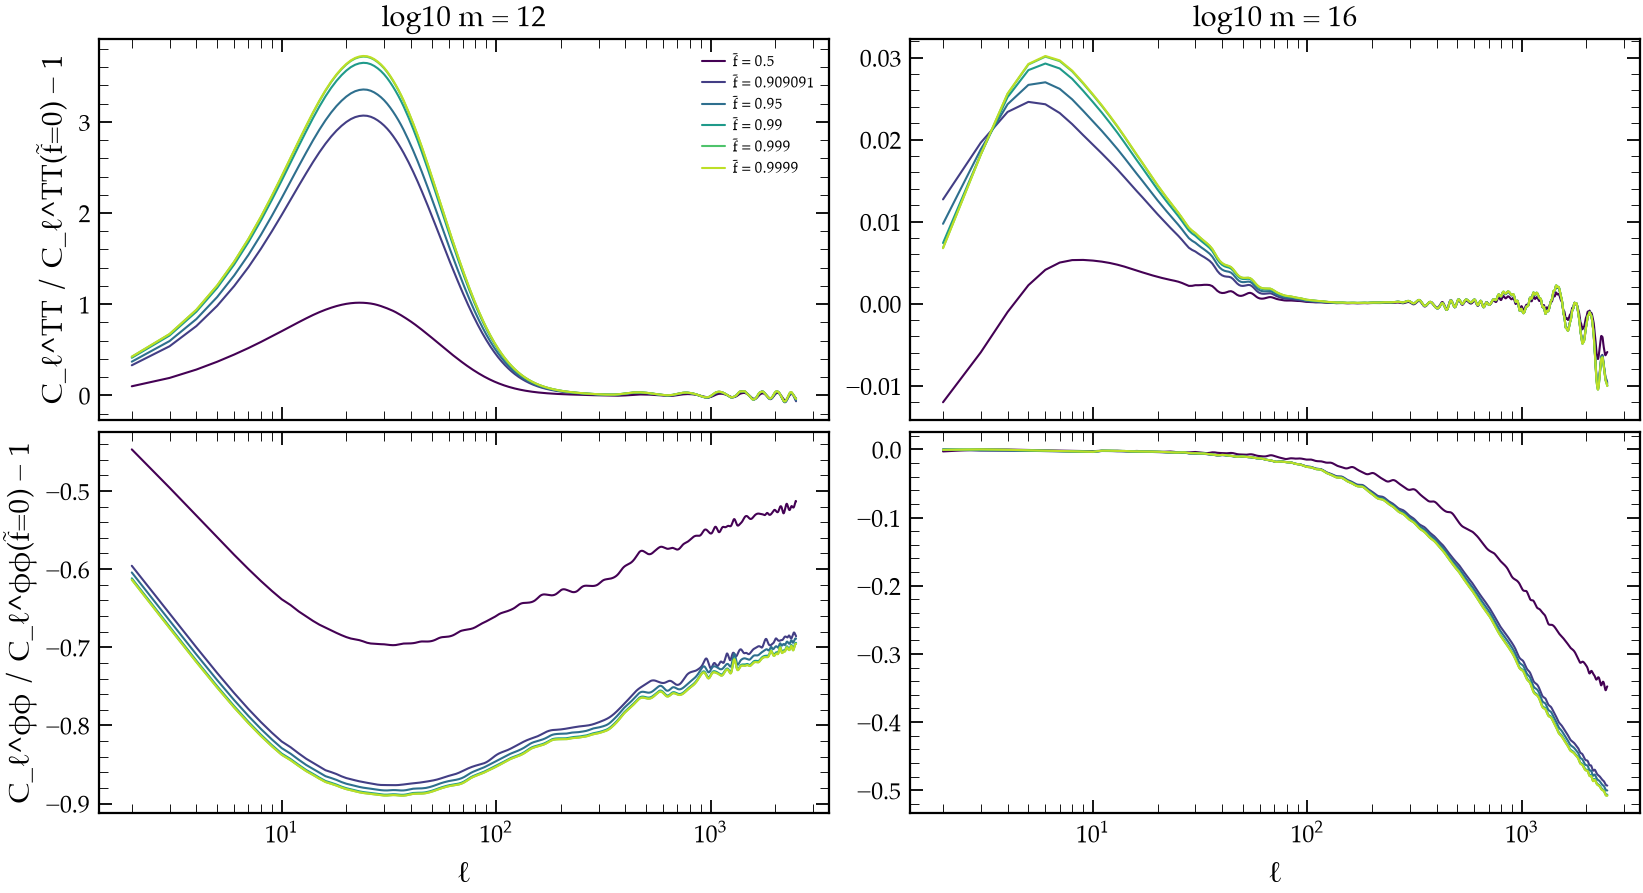

In [6]:
F_BIG = [0.0, 0.5, 10/11, 0.95, 0.99, 0.999, 0.9999]
BIG_M = [12, 16]
grid = [(lm, ft) for lm in BIG_M for ft in F_BIG]
big_out = run_all(run, [{**SETTINGS, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT, 'm_acc_in_GeV': 10**lm,
                          'f_tilde': ft} for lm, ft in grid])
big = dict(zip(grid, big_out))

rows = []
for (lm, ft), o in big.items():
    ref = big[(lm, 0.0)]
    row = {'log10m': lm, 'f_tilde': ft, 'f_acc': ft/(1 - ft), 'status': o.get('error', 'ok')}
    if 'error' not in o:
        row.update({'time [s]': o['time'], 'omega_cdm': o['omega_cdm'], 'sigma8': o['sigma8'],
                    '100theta_s': o['100theta_s'],
                    'max |dC_l^TT|/C_l': np.max(np.abs(o['tt']/ref['tt'] - 1)),
                    'max |dC_l^pp|/C_l': np.max(np.abs(o['pp']/ref['pp'] - 1))})
    rows.append(row)
show(pd.DataFrame(rows).set_index(['log10m', 'f_tilde']),
     {'f_acc': '{:.4g}', 'time [s]': '{:.1f}', 'omega_cdm': '{:.2e}', 'sigma8': '{:.4f}', '100theta_s': '{:.5f}',
      'max |dC_l^TT|/C_l': '{:.3f}', 'max |dC_l^pp|/C_l': '{:.3f}'})

ell = np.arange(2, LMAX + 1)
fig, axes = plt.subplots(2, len(BIG_M), figsize=(5.5*len(BIG_M), 6), sharex=True, squeeze=False,
                         constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(F_BIG) - 1))
for j, lm in enumerate(BIG_M):
    ref = big[(lm, 0.0)]
    for c, ft in zip(colors, F_BIG[1:]):
        o = big[(lm, ft)]
        if 'error' in o:
            continue
        axes[0, j].plot(ell, o['tt']/ref['tt'] - 1, color=c, lw=1, label='f̃ = {:g}'.format(ft))
        axes[1, j].plot(ell, o['pp']/ref['pp'] - 1, color=c, lw=1)
    axes[0, j].set_title('log10 m = {:g}'.format(lm))
    axes[1, j].set_xlabel('ℓ')
    axes[1, j].set_xscale('log')
axes[0, 0].set_ylabel('C_ℓ^TT / C_ℓ^TT(f̃=0) − 1')
axes[1, 0].set_ylabel('C_ℓ^φφ / C_ℓ^φφ(f̃=0) − 1')
axes[0, 0].legend(fontsize=7)
plt.show()

time [s] max |dC_l^TT|/C_l max |dC_l^pp|/C_l  \
log10m f_tilde bins/decade                                                    
12     0.10    50 vs 200            9.8           2.0e-03           2.2e-03   
               100 vs 200          18.9           1.7e-03           1.2e-03   
               200 (reference)     41.2                 -                 -   
       0.50    50 vs 200            9.5           3.1e-02           1.5e-02   
               100 vs 200          19.2           1.2e-02           5.3e-03   
               200 (reference)     43.3                 -                 -   
       0.99    50 vs 200            9.7           9.5e-02           3.3e-02   
               100 vs 200          19.4           4.3e-02           2.0e-02   
               200 (reference)     40.5                 -                 -   
16     0.10    50 vs 200            8.1           7.9e-04           1.1e-03   
               100 vs 200          16.3           1.4e-03           9.7e-04   
               200 (reference)     35.8                 -                 -   
       0.50    50 vs 200            8.3           1.4e-02           7.1e-03   
               100 vs 200          16.8           1.8e-03           2.6e-03   
               200 (reference)     37.3                 -                 -   
       0.99    50 vs 200            8.3           2.6e-02           8.0e-03   
               100 vs 200          17.0           5.5e-03           5.7e-03   
               200 (reference)     37.9                 -                 -   

                               |dsigma8|/sigma8  
log10m f_tilde bins/decade                       
12     0.10    50 vs 200                2.0e-04  
               100 vs 200               4.0e-05  
               200 (reference)                -  
       0.50    50 vs 200                5.5e-03  
               100 vs 200               1.1e-03  
               200 (reference)                -  
       0.99    50 vs 200                2.4e-02  
               100 vs 200               4.7e-03  
               200 (reference)                -  
16     0.10    50 vs 200                6.1e-05  
               100 vs 200               1.2e-05  
               200 (reference)                -  
       0.50    50 vs 200                1.2e-03  
               100 vs 200               2.3e-04  
               200 (reference)                -  
       0.99    50 vs 200                2.8e-03  
               100 vs 200               5.1e-04  
               200 (reference)                -

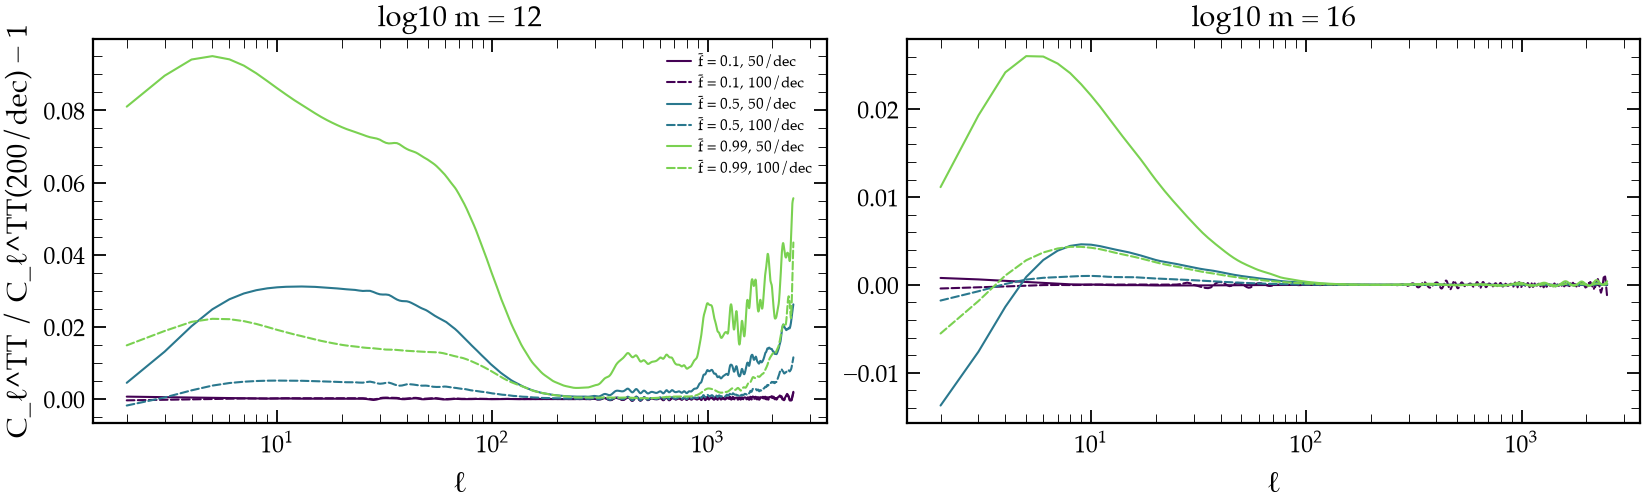

In [7]:
CONV_F = [0.1, 0.5, 0.99]
CONV_BINS = [50, 100, 200]                                   # 50 is the default
conv = {(lm, ft, nb): run({**SETTINGS, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT, 'm_acc_in_GeV': 10**lm,
                           'f_tilde': ft, 'accdm_q_bins_per_decade': nb})
        for lm in BIG_M for ft in CONV_F for nb in CONV_BINS}
assert all('error' not in o for o in conv.values()), [o['error'] for o in conv.values() if 'error' in o]
rows = []
for lm in BIG_M:
    for ft in CONV_F:
        best = conv[(lm, ft, CONV_BINS[-1])]
        for nb in CONV_BINS[:-1]:
            o = conv[(lm, ft, nb)]
            rows.append({'log10m': lm, 'f_tilde': ft, 'bins/decade': '{} vs {}'.format(nb, CONV_BINS[-1]),
                         'time [s]': o['time'],
                         'max |dC_l^TT|/C_l': np.max(np.abs(o['tt']/best['tt'] - 1)),
                         'max |dC_l^pp|/C_l': np.max(np.abs(o['pp']/best['pp'] - 1)),
                         '|dsigma8|/sigma8': abs(o['sigma8']/best['sigma8'] - 1)})
        rows.append({'log10m': lm, 'f_tilde': ft, 'bins/decade': '{} (reference)'.format(CONV_BINS[-1]),
                     'time [s]': best['time']})
show(pd.DataFrame(rows).set_index(['log10m', 'f_tilde', 'bins/decade']),
     {'time [s]': '{:.1f}', 'max |dC_l^TT|/C_l': '{:.1e}', 'max |dC_l^pp|/C_l': '{:.1e}', '|dsigma8|/sigma8': '{:.1e}'})

fig, axes = plt.subplots(1, len(BIG_M), figsize=(5.5*len(BIG_M), 3.4), squeeze=False, constrained_layout=True)
for ax, lm in zip(axes[0], BIG_M):
    for c, ft in zip(plt.cm.viridis(np.linspace(0, 0.8, len(CONV_F))), CONV_F):
        for nb, ls in zip(CONV_BINS[:-1], ('-', '--')):
            ax.plot(ell, conv[(lm, ft, nb)]['tt']/conv[(lm, ft, CONV_BINS[-1])]['tt'] - 1, ls, color=c, lw=1,
                    label='f̃ = {:g}, {}/dec'.format(ft, nb))
    ax.set_xscale('log')
    ax.set_xlabel('ℓ')
    ax.set_title('log10 m = {:g}'.format(lm))
axes[0, 0].set_ylabel('C_ℓ^TT / C_ℓ^TT({}/dec) − 1'.format(CONV_BINS[-1]))
axes[0, 0].legend(fontsize=7)
plt.show()

## 4. Response of the observables

σ8 along f̃ at fixed ω_dm,tot, over the range both priors share (f̃ ≤ 10/11, f_acc ≤ 10), for daughters warm
enough to suppress structure. The grid is uniform in f̃. A response close to linear in the sampled coordinate is
easier for the emulator to learn; the table gives the largest residual of a straight-line fit in each coordinate,
relative to the total change of σ8 over the range.

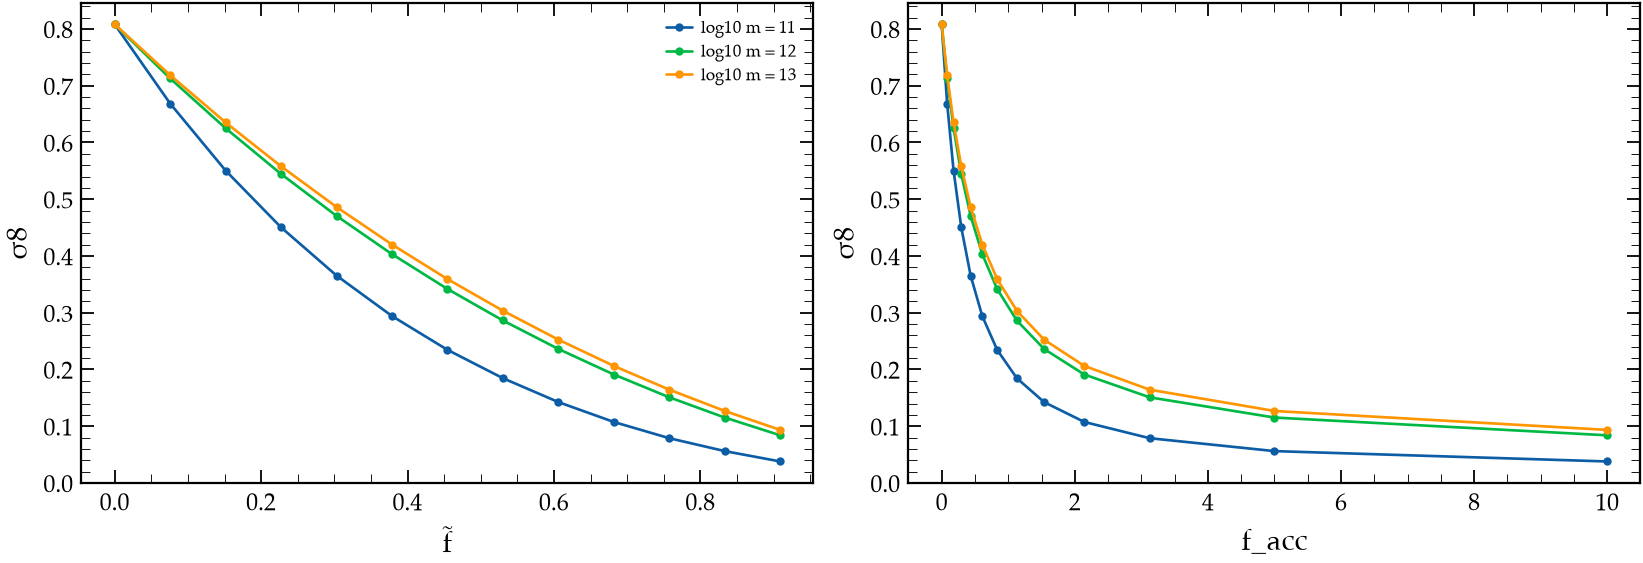

,sigma8(0),sigma8(10/11),"residual, linear in f_tilde","residual, linear in f_acc"
log10m,,,,
11,0.8081,0.0379,0.1744,0.5081
12,0.8081,0.0840,0.0929,0.4276
13,0.8081,0.0935,0.0815,0.4155


In [8]:
RESP_M = [11, 12, 13]
RESP_F = np.linspace(0, 10/11, 13)
grid = [(lm, ft) for lm in RESP_M for ft in RESP_F]
resp_out = run_all(run, [{**MPK_SETTINGS, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT, 'm_acc_in_GeV': 10**lm,
                           'f_tilde': ft} for lm, ft in grid])
assert all('error' not in o for o in resp_out)
sig = {lm: np.array([o['sigma8'] for (m, _), o in zip(grid, resp_out) if m == lm]) for lm in RESP_M}


def linear_residual(x, y):
    fit = np.polyval(np.polyfit(x, y, 1), x)
    return np.max(np.abs(y - fit))/abs(y[-1] - y[0])


fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
rows = []
for lm in RESP_M:
    axes[0].plot(RESP_F, sig[lm], 'o-', ms=3, label='log10 m = {:g}'.format(lm))
    axes[1].plot(RESP_F/(1 - RESP_F), sig[lm], 'o-', ms=3)
    rows.append({'log10m': lm, 'sigma8(0)': sig[lm][0], 'sigma8(10/11)': sig[lm][-1],
                 'residual, linear in f_tilde': linear_residual(RESP_F, sig[lm]),
                 'residual, linear in f_acc': linear_residual(RESP_F/(1 - RESP_F), sig[lm])})
axes[0].set_xlabel('f̃')
axes[1].set_xlabel('f_acc')
for ax in axes:
    ax.set_ylabel('σ8')
axes[0].legend(fontsize=8)
plt.show()
display(pd.DataFrame(rows).set_index('log10m').round(4))

## 5. The prior

A flat prior on one coordinate is not flat on the other:

- flat f̃ on [0, 1)  ⇔  p(f_acc) = (1 + f_acc)⁻² on [0, ∞);
- flat f_acc on [0, f_max]  ⇔  p(f̃) = (1 − f̃)⁻²/f_max on [0, f_max/(1 + f_max)].

So flat f̃ gives half its weight to f_acc < 1, where flat f_acc on [0, 10] gives 10%, and has a tail beyond f_max
that flat f_acc cuts off. With the second coordinate included, the weights that turn the chains' flat
(ω_dm,tot, f_acc) prior into the others are the Jacobians

| flat in | weight relative to flat (ω_dm,tot, f_acc) |
|---|---|
| (ω_dm,tot, f_acc) | 1 (as sampled) |
| (ω_cdm, f_acc) | (1 + f_acc)⁻¹ (nb34) |
| (ω_dm,tot, f̃) | (1 + f_acc)⁻² |
| (ω_cdm, f̃) | (1 + f_acc)⁻³ |

prior mass per band


,f_tilde band,"flat f_acc [0,1]","flat f_acc [0,5]","flat f_acc [0,10]","flat f_tilde [0,1)"
f_acc band,,,,,
"[0, 0.01)","[0, 0.0099)",0.01,0.002,0.001,0.0099
"[0.01, 0.1)","[0.0099, 0.0909)",0.09,0.018,0.009,0.0810
"[0.1, 1)","[0.0909, 0.5)",0.90,0.180,0.090,0.4091
"[1, 5)","[0.5, 0.833)",0.00,0.800,0.400,0.3333
"[5, 10)","[0.833, 0.909)",0.00,0.000,0.500,0.0758
"[10, inf)","[0.909, 1)",0.00,0.000,0.000,0.0909


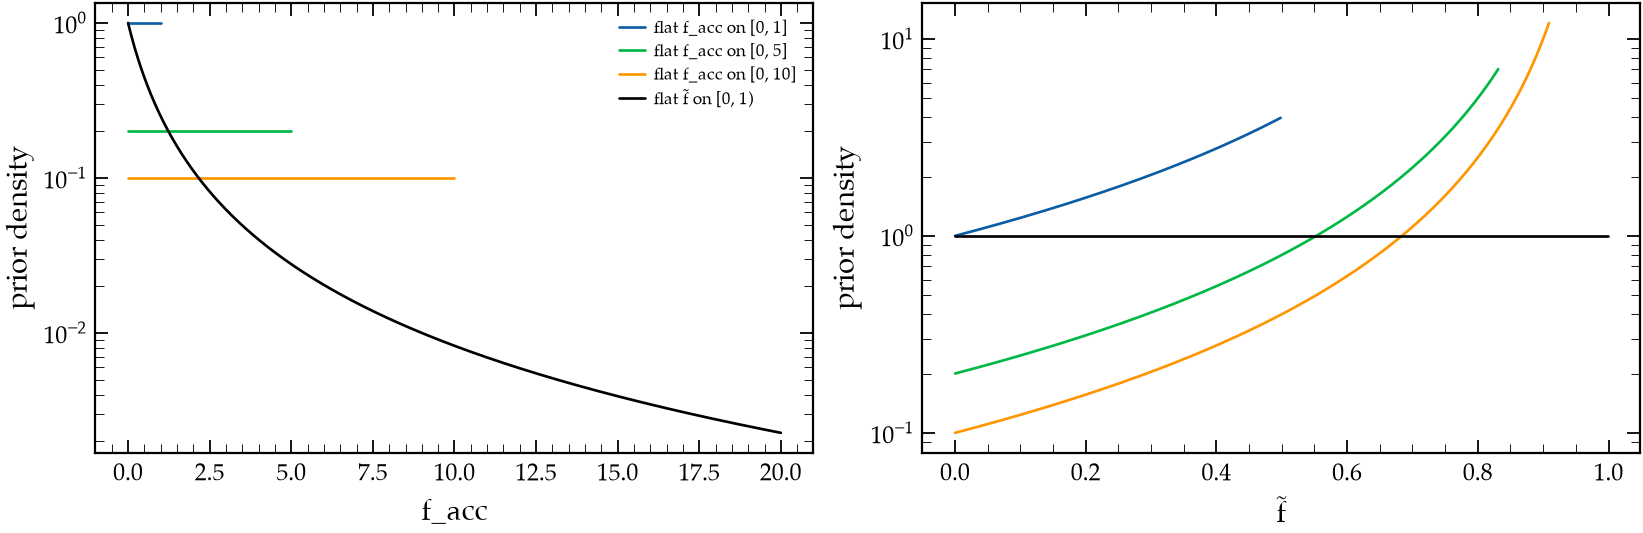

In [9]:
BANDS = [(0, 0.01), (0.01, 0.1), (0.1, 1), (1, 5), (5, 10), (10, np.inf)]
mass_flat_f = lambda a, b, fmax: (min(b, fmax) - min(a, fmax))/fmax
mass_flat_ft = lambda a, b: (1 if np.isinf(b) else b/(1 + b)) - a/(1 + a)
rows = []
for a, b in BANDS:
    row = {'f_acc band': '[{:g}, {:g})'.format(a, b),
           'f_tilde band': '[{:.3g}, {:.3g})'.format(a/(1 + a), 1 if np.isinf(b) else b/(1 + b))}
    for fmax in (1, 5, 10):
        row['flat f_acc [0,{}]'.format(fmax)] = mass_flat_f(a, b, fmax)
    row['flat f_tilde [0,1)'] = mass_flat_ft(a, b)
    rows.append(row)
print('prior mass per band')
display(pd.DataFrame(rows).set_index('f_acc band').round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
f = np.linspace(0, 20, 801)
ft = np.linspace(0, 0.999, 400)
for fmax in (1, 5, 10):
    axes[0].plot(f, np.where(f <= fmax, 1/fmax, np.nan), label='flat f_acc on [0, {}]'.format(fmax))
    axes[1].plot(ft, np.where(ft <= fmax/(1 + fmax), (1 - ft)**-2/fmax, np.nan))
axes[0].plot(f, (1 + f)**-2, 'k', label='flat f̃ on [0, 1)')
axes[1].plot(ft, np.ones_like(ft), 'k')
axes[0].set_xlabel('f_acc')
axes[0].set_yscale('log')
axes[0].legend(fontsize=8)
axes[1].set_xlabel('f̃')
axes[1].set_yscale('log')
for ax in axes:
    ax.set_ylabel('prior density')
plt.show()

### 5b. Reweighted chains

Multiplying the chain weights by the table above previews the other priors, but only on f̃ ≤ f_max/(1 + f_max):
the flat-f̃ prior's tail beyond is not sampled. Where the sampled posterior still has weight near f_max (the
P(f_acc > 0.9 f_max) column), the reweighted f̃ limits are set by that truncation, not by the data. The ESS ratio
says how much of the chain survives the reweighting to flat (ω_dm,tot, f̃).

,f_max,P(f_acc > 0.9 f_max),"f̃ 95%, flat (omega_dm_tot, f_acc)","f̃ 95%, flat (omega_cdm, f_acc)","f̃ 95%, flat (omega_dm_tot, f_tilde)","f̃ 95%, flat (omega_cdm, f_tilde)",ESS ratio
log10m,,,,,,,
11.000,10.0,0.000,0.007,0.007,0.006,0.006,0.999
12.000,10.0,0.000,0.012,0.012,0.012,0.012,0.998
13.000,1.0,0.000,0.017,0.016,0.016,0.016,0.997
14.000,5.0,0.000,0.026,0.026,0.026,0.025,0.995
15.000,10.0,0.000,0.079,0.077,0.075,0.073,0.984
15.301,10.0,0.000,0.122,0.118,0.114,0.110,0.973
15.699,10.0,0.000,0.302,0.273,0.249,0.231,0.911
16.000,10.0,0.009,0.844,0.592,0.447,0.368,0.674
16.301,10.0,0.052,0.900,0.865,0.712,0.561,0.324


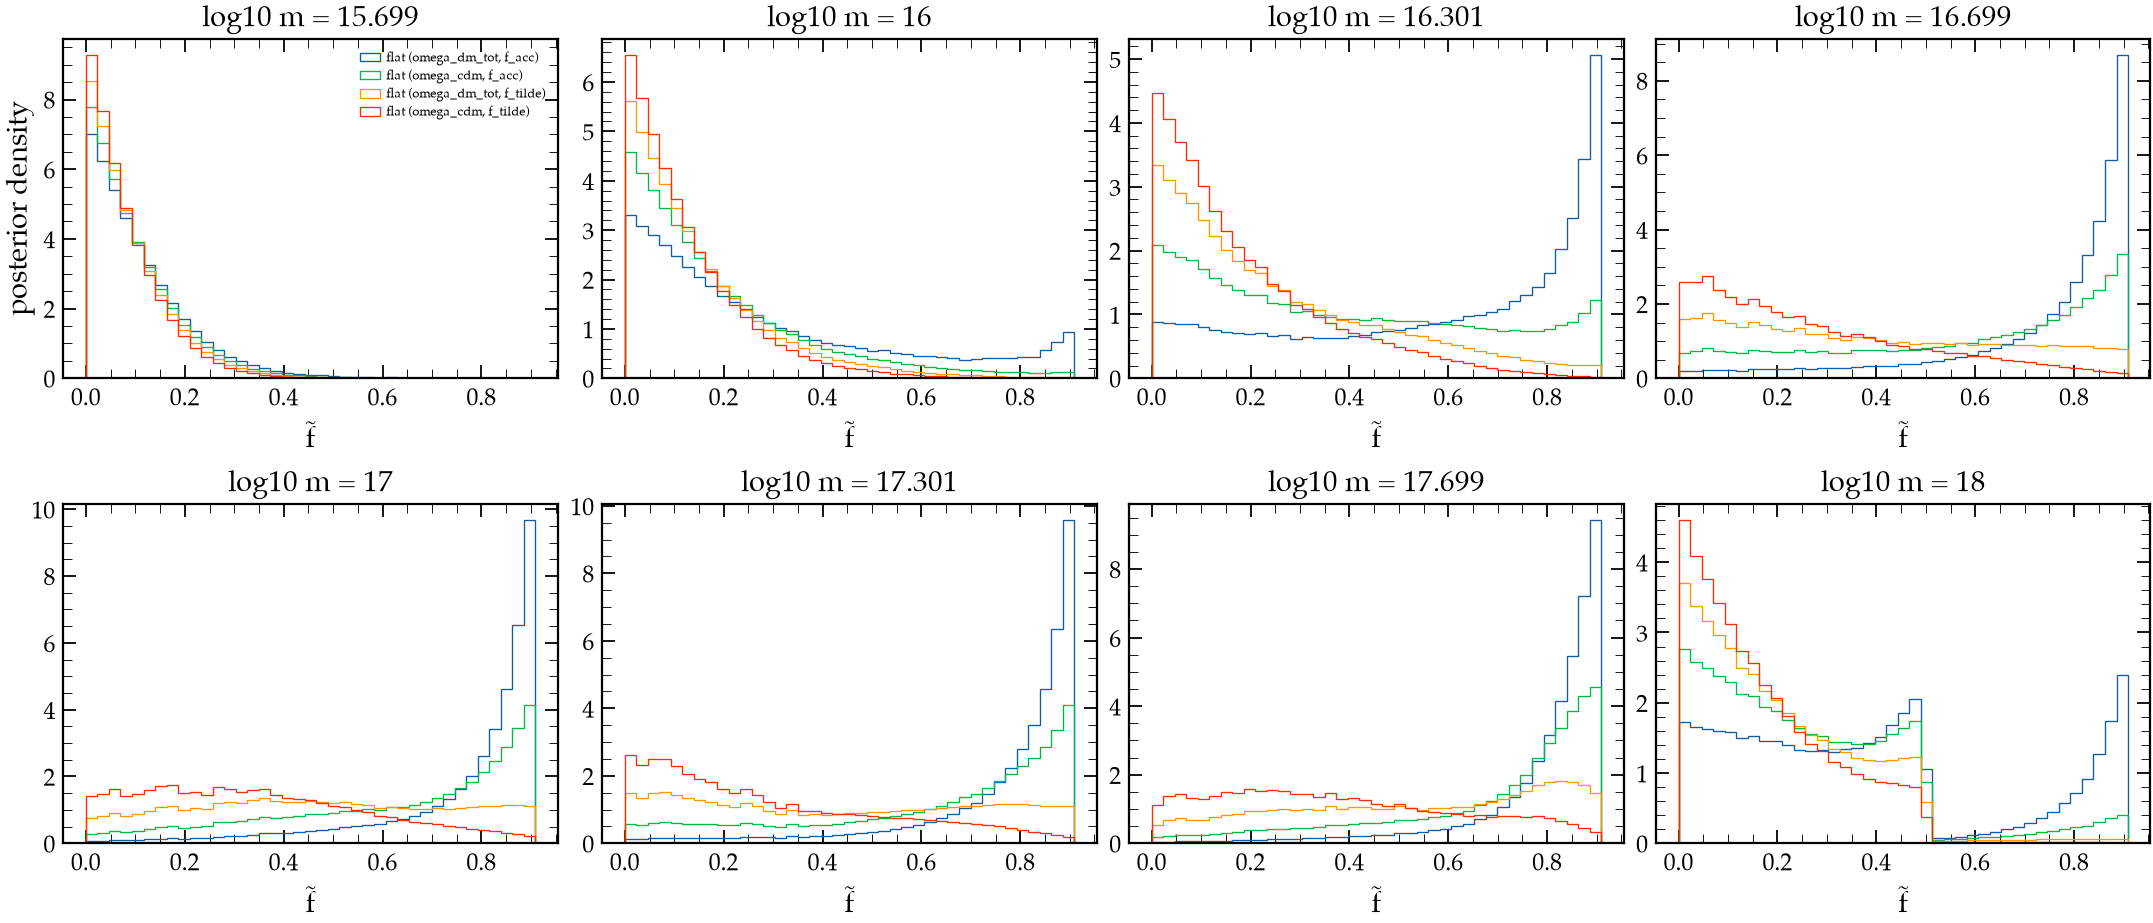

In [10]:
PRIORS = {'flat (omega_dm_tot, f_acc)': lambda f: np.ones_like(f),
          'flat (omega_cdm, f_acc)':    lambda f: (1 + f)**-1,
          'flat (omega_dm_tot, f_tilde)': lambda f: (1 + f)**-2,
          'flat (omega_cdm, f_tilde)':  lambda f: (1 + f)**-3}

rows = []
for m, s in SAMPLES.items():
    w = s['weight']
    row = {'log10m': m, 'f_max': s['f_max'], 'P(f_acc > 0.9 f_max)': wmean(s['f_acc'] > 0.9*s['f_max'], w)}
    for label, prior in PRIORS.items():
        row['f̃ 95%, ' + label] = wquantile(s['f_tilde'], w*prior(s['f_acc']), 0.95)
    row['ESS ratio'] = ess(w*PRIORS['flat (omega_dm_tot, f_tilde)'](s['f_acc']))/ess(w)
    rows.append(row)
reweighted = pd.DataFrame(rows).set_index('log10m')
display(reweighted.round(3))

SHOW = [m for m in SAMPLES if wmean(SAMPLES[m]['f_acc'], SAMPLES[m]['weight']) > 0.05]
ncol = 4
nrow = -(-len(SHOW)//ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6*ncol, 3.1*nrow), squeeze=False, constrained_layout=True)
for ax, m in zip(axes.flat, SHOW):
    s = SAMPLES[m]
    edges = np.linspace(0, s['f_max']/(1 + s['f_max']), 40)
    for label, prior in PRIORS.items():
        ax.hist(s['f_tilde'], edges, weights=s['weight']*prior(s['f_acc']), density=True, histtype='step',
                label=label)
    ax.set_title('log10 m = {:g}'.format(m))
    ax.set_xlabel('f̃')
for ax in axes.flat[len(SHOW):]:
    ax.set_visible(False)
axes[0, 0].set_ylabel('posterior density')
axes[0, 0].legend(fontsize=6)
plt.show()

## 6. Training coverage

The first CONNECT iteration is a Latin hypercube over the prior box, so the fraction of its points that land where
each mass's posterior lives is set by the prior in f. For each chain: the central 95% interval of f_acc (as sampled)
and the fraction of an 8000-point LHC that falls inside it, for f_acc uniform on that chain's [0, f_max] and for
f̃ uniform on [0, 1). The other parameters cut both boxes equally and are left out.

In [11]:
N_LHC = 8000
u = qmc.LatinHypercube(d=1, seed=1).random(N_LHC)[:, 0]
f_from_ft = u/(1 - u)

rows = []
for m, s in SAMPLES.items():
    lo, hi = (wquantile(s['f_acc'], s['weight'], q) for q in (0.025, 0.975))
    inside = lambda f: np.mean((f >= lo) & (f <= hi))
    rows.append({'log10m': m, 'f_max': s['f_max'], 'f_acc 2.5%': lo, 'f_acc 97.5%': hi,
                 'LHC inside, flat f_acc': inside(s['f_max']*u),
                 'LHC inside, flat f_tilde': inside(f_from_ft)})
coverage = pd.DataFrame(rows).set_index('log10m')
coverage['ratio'] = coverage['LHC inside, flat f_tilde']/coverage['LHC inside, flat f_acc']
show(coverage, {c: '{:.3g}' for c in coverage.columns})
for fmax in (1, 5, 10):
    print('flat f_tilde LHC points beyond f_acc = {:g}: {:.1%}'.format(fmax, np.mean(f_from_ft > fmax)))

,f_max,f_acc 2.5%,f_acc 97.5%,"LHC inside, flat f_acc","LHC inside, flat f_tilde",ratio
log10m,,,,,,
11.000,10,6.71e-05,0.00798,0.00075,0.00788,10.5
12.000,10,0.000113,0.0148,0.0015,0.0144,9.58
13.000,1,0.000164,0.0203,0.0201,0.0196,0.975
14.000,5,0.000252,0.0325,0.0065,0.0312,4.81
15.000,10,0.000802,0.104,0.0104,0.0938,9.04
15.301,10,0.00127,0.17,0.0169,0.144,8.53
15.699,10,0.00335,0.571,0.0568,0.36,6.35
16.000,10,0.00748,7.48,0.747,0.875,1.17
16.301,10,0.0283,9.52,0.949,0.877,0.924


flat f_tilde LHC points beyond f_acc = 1: 50.0%
flat f_tilde LHC points beyond f_acc = 5: 16.7%
flat f_tilde LHC points beyond f_acc = 10: 9.1%


## Reading the result

- **Section 1:** `f_tilde` is a pure change of input. Every f̃ run is bit-identical to the f_acc run given
  f̃/(1 − f̃), with ω_dm,tot or ω_cdm, and bad inputs stop at input with a clear message.
- **Section 1c:** f̃/(1 − f̃) can land one ulp away from the nominal f_acc (f_acc = 5, 10). That alone moves the
  lensed spectra by up to ~10⁻⁴ of their peak, mostly at ℓ = 2, and σ8 by ~10⁻⁹. A 10⁻¹² nudge of f_acc does the
  same with no f̃ involved, so this is CLASS's own repeatability floor, the same for any parametrization.
- **Section 2:** f̃ is the parent share before the transition to round-off. Today it is the accDM share of the
  dark matter to 2.5% (relative) at 10¹¹ GeV and f̃ = 0.1, and better than 2·10⁻⁵ from 10¹⁴ GeV up.
- **Section 3:** CLASS runs fine up to f̃ = 0.9999 (f_acc ≈ 10⁴), at the same ~8 s per run, as ω_cdm → 0. Beyond
  f_acc ≈ 10 the observables have nearly saturated: at 10¹⁶ GeV σ8 only goes from 0.588 to 0.571. A flat f̃ prior
  puts 9% of its mass on this near-plateau.
- **Section 3, convergence (independent of f̃, but it matters for the chains):** the default daughter grid
  (`accdm_q_bins_per_decade = 50`) is not converged once the daughter is a large share of the dark matter.
  Against 200/decade, TT is off by 0.2% / 3.1% / 9.5% at 10¹² GeV for f̃ = 0.1 / 0.5 / 0.99, and by
  0.08% / 1.4% / 2.6% at 10¹⁶ GeV. σ8 is off by up to 2.4% (10¹² GeV, f̃ = 0.99). 100/decade is still ~1% off at
  10¹² GeV. At 10¹⁶ GeV the error sits at ℓ ≲ 100, where cosmic variance is large. At 10¹² GeV it also reaches
  ℓ > 10³, but the chains there allow only f̃ ≲ 0.01, where the grid is fine. Worth a dedicated check before
  trusting the high-f̃ end of the high-mass chains.
- **Section 4:** σ8 is much closer to linear in f̃ than in f_acc. The worst straight-line residual is 8–17% of the
  total change in f̃, against 42–51% in f_acc. All the response sits at small f_acc, which f̃ stretches out.
- **Section 5:** this is the physical difference. Up to 10¹⁵·³ GeV the 95% limits barely depend on the prior.
  From 10¹⁵·⁷ GeV up they do, strongly. Flat (ω_dm,tot, f̃) lowers the f̃ limit at 10¹⁶ GeV from 0.84 to 0.45.
  From 10¹⁶·³ GeV up, 5–10% of the sampled posterior sits within 10% of f_max: the data do not bound f_acc
  there, and every "limit" is the prior edge. Under flat f̃ that edge moves to f̃ = 1, beyond what these chains
  sampled, and the reweighting keeps only 20–30% of the samples. Read these as previews; quoting limits needs
  new chains in f̃. The 10¹⁸ GeV chain has a sharp step at f̃ = 0.5 (f_acc = 1) under every prior. That is in
  the chain itself (emulator or sampling), not in the reweighting.
- **Section 6:** where the posterior hugs f_acc ≈ 0 (≤ 10¹⁵·⁷ GeV), a flat-f̃ LHC puts 5–10× more first-iteration
  training points on it. Where the posterior spans the whole box (≥ 10¹⁶·³ GeV), it puts 0.65–0.9× as many, since
  9% of the points go beyond f_acc = 10.

To switch a fixed-mass run:

- MontePython: replace the f_acc line with `data.parameters['f_tilde'] = [0.01, 0.0, 0.999, 0.01, 1, 'cosmo']`.
  Use an upper bound just below 1, because f̃ = 1 is an input error. classy raises it as `CosmoSevereError`, which
  stops MontePython instead of rejecting the point. The lost prior mass (0.1%) sits where the observables have
  saturated (section 3).
- CONNECT: replace `'f_acc': [0, f_max]` in `parameters` with `'f_tilde': [0, 0.999]`.
- Post-processing: f_acc = f̃/(1 − f̃), ω_cdm = ω_dm,tot·(1 − f̃).